In [18]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA

# Machine Learning - Models
from sklearn.ensemble import RandomForestClassifier, IsolationForest, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Machine Learning - Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('ggplot')

print("All libraries imported successfully!")

All libraries imported successfully!


# =====================================================================
# PREPROCESSING
# =====================================================================

## Step 1: Handling Identifier and Temporal Columns

In [19]:
# Load the dataset
df = pd.read_csv('/Users/ayoubkallel/PFA2/-Intelligent-Anomaly-Monitoring-in-5G-networks/Data/Model_data.csv')

# Convert timestamp column to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

print("✅ Dataset loaded successfully!")
print(f"📊 Dataset dimensions: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"📅 Period covered: {df['timestamp'].min()} to {df['timestamp'].max()}")

✅ Dataset loaded successfully!
📊 Dataset dimensions: 210,528 rows × 23 columns
📅 Period covered: 2024-01-01 00:00:23 to 2025-12-31 23:55:00


In [20]:
# =====================================================================
# 1.1 Extract temporal components from timestamp
# =====================================================================

df['year']   = df['timestamp'].dt.year
df['month']  = df['timestamp'].dt.month
df['day']    = df['timestamp'].dt.day
df['hour']   = df['timestamp'].dt.hour
df['minute'] = df['timestamp'].dt.minute
df['second'] = df['timestamp'].dt.second
df['date'] = df['timestamp'].dt.date

print("Temporal columns extracted:")
print(df[['timestamp', 'year', 'month', 'day', 'hour', 'minute', 'second']].head(10))

Temporal columns extracted:
            timestamp  year  month  day  hour  minute  second
0 2024-01-01 00:00:23  2024      1    1     0       0      23
1 2024-01-01 00:05:07  2024      1    1     0       5       7
2 2024-01-01 00:10:21  2024      1    1     0      10      21
3 2024-01-01 00:14:31  2024      1    1     0      14      31
4 2024-01-01 00:20:09  2024      1    1     0      20       9
5 2024-01-01 00:24:30  2024      1    1     0      24      30
6 2024-01-01 00:30:07  2024      1    1     0      30       7
7 2024-01-01 00:34:43  2024      1    1     0      34      43
8 2024-01-01 00:39:56  2024      1    1     0      39      56
9 2024-01-01 00:45:17  2024      1    1     0      45      17


In [21]:
# =====================================================================
# 1.2 Drop non-predictive identifier and high correlated columns
# =====================================================================
# timestamp is kept in the DataFrame for reference but will be excluded from features (X) during modeling

columns_to_drop = ['cell_id', 'ue_id', 'date','packet_loss_rate_percent','rtt_ms','energy_efficiency_bits_per_joule','reliability_percent','throughput_ul_mbps','spectral_efficiency_bps_hz','bler_percent']
df.drop(columns=columns_to_drop, inplace=True)

print(f"Dropped columns: {columns_to_drop}")
print(f"Note: 'timestamp' is kept in the DataFrame but will be excluded from features during modeling.")
print(f"\nNew dataset dimensions: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nRemaining columns:\n{list(df.columns)}")

Dropped columns: ['cell_id', 'ue_id', 'date', 'packet_loss_rate_percent', 'rtt_ms', 'energy_efficiency_bits_per_joule', 'reliability_percent', 'throughput_ul_mbps', 'spectral_efficiency_bps_hz', 'bler_percent']
Note: 'timestamp' is kept in the DataFrame but will be excluded from features during modeling.

New dataset dimensions: 210,528 rows x 19 columns

Remaining columns:
['timestamp', 'slice_type', 'latitude', 'longitude', 'one_way_latency_ms', 'jitter_ms', 'packet_delay_budget_ms', 'handover_interruption_time_ms', 'packet_loss_percent', 'throughput_dl_mbps', 'handover_success_rate_percent', 'anomaly', 'anomaly_type', 'year', 'month', 'day', 'hour', 'minute', 'second']


In [22]:
# =====================================================================
# 1.3 Encode slice_type (Label Encoding)
# =====================================================================
# Only 3 categories (eMBB, URLLC, mMTC) -> Label Encoding is sufficient

le_slice = LabelEncoder()
df['slice_type'] = le_slice.fit_transform(df['slice_type'])

print("slice_type encoding (Label Encoding):")
for label, encoded in zip(le_slice.classes_, le_slice.transform(le_slice.classes_)):
    print(f"   {label} -> {encoded}")

print(f"\nDistribution after encoding:")
print(df['slice_type'].value_counts().sort_index())

slice_type encoding (Label Encoding):
   URLLC -> 0
   eMBB -> 1
   mMTC -> 2

Distribution after encoding:
slice_type
0     63196
1    105214
2     42118
Name: count, dtype: int64


In [23]:
# =====================================================================
# 1.4 DataFrame state verification after Step 1
# =====================================================================

print("="*70)
print("VERIFICATION - DATAFRAME STATE AFTER STEP 1")
print("="*70)
print(f"\nDimensions: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nColumn types:")
print(df.dtypes)
print(f"\nPreview:")
df.head()

VERIFICATION - DATAFRAME STATE AFTER STEP 1

Dimensions: 210,528 rows x 19 columns

Column types:
timestamp                        datetime64[ns]
slice_type                                int64
latitude                                float64
longitude                               float64
one_way_latency_ms                      float64
jitter_ms                               float64
packet_delay_budget_ms                  float64
handover_interruption_time_ms           float64
packet_loss_percent                     float64
throughput_dl_mbps                      float64
handover_success_rate_percent           float64
anomaly                                   int64
anomaly_type                             object
year                                      int32
month                                     int32
day                                       int32
hour                                      int32
minute                                    int32
second                                

,timestamp,slice_type,latitude,longitude,one_way_latency_ms,jitter_ms,packet_delay_budget_ms,handover_interruption_time_ms,packet_loss_percent,throughput_dl_mbps,handover_success_rate_percent,anomaly,anomaly_type,year,month,day,hour,minute,second
0,2024-01-01 00:00:23,1,33.986761,-7.481772,8.2701,6.4668,93.2862,17.2102,0.384824,16319.8043,99.5330,0,normal,2024,1,1,0,0,23
1,2024-01-01 00:05:07,1,33.924364,-7.688178,6.5374,5.6247,72.3138,24.1853,0.282045,8838.0518,99.4285,0,normal,2024,1,1,0,5,7
2,2024-01-01 00:10:21,0,33.874334,-7.592654,2.9853,0.7240,0.6080,4.4692,0.000878,41.8399,99.1853,0,normal,2024,1,1,0,10,21
3,2024-01-01 00:14:31,0,33.986101,-7.489073,2.4752,0.6764,0.6122,6.0127,0.000431,55.8908,99.6506,0,normal,2024,1,1,0,14,31
4,2024-01-01 00:20:09,1,33.722701,-7.533619,14.6547,15.7102,71.8194,37.8084,9.553508,4345.8090,99.7065,1,interference,2024,1,1,0,20,9


In [24]:
# =====================================================================
# Create a clean copy of the DataFrame for preprocessing
# =====================================================================
# df is preserved as the original (post-Step 1), df_clean is used from now on

df_clean = df.copy()

print(f"df_clean created: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns")
print(f"Original df is preserved separately.")

df_clean created: 210,528 rows x 19 columns
Original df is preserved separately.


## 2. Feautres and Target Separation:

In [25]:
# =====================================================================
# 2.1 Define Features (X) and Targets (y1, y2)
# =====================================================================

# Columns to exclude from features
exclude_cols = ['timestamp', 'anomaly', 'anomaly_type']

# Features: 14 KPIs + slice_type (encoded) + latitude + longitude + 6 temporal components
X = df_clean.drop(columns=exclude_cols)

# Target 1: Binary classification (0 = Normal, 1 = Anomaly)
y1 = df_clean['anomaly']

# Target 2: Multi-class classification (8 anomaly types)
le_anomaly = LabelEncoder()
y2 = le_anomaly.fit_transform(df_clean['anomaly_type'])

print("="*70)
print("FEATURES / TARGETS SEPARATION")
print("="*70)

print(f"\nFeatures (X): {X.shape[1]} columns")
print(f"   {list(X.columns)}")
print(f"\nTarget y1 (binary): anomaly")
print(f"   Classes: {sorted(y1.unique())} -> 0=Normal, 1=Anomaly")
print(f"   Distribution: {dict(y1.value_counts().sort_index())}")
print(f"\nTarget y2 (multi-class): anomaly_type")
print(f"   Encoding:")
for label, encoded in zip(le_anomaly.classes_, le_anomaly.transform(le_anomaly.classes_)):
    print(f"      {label} -> {encoded}")
print(f"   Distribution: {dict(pd.Series(y2).value_counts().sort_index())}")

FEATURES / TARGETS SEPARATION

Features (X): 16 columns
   ['slice_type', 'latitude', 'longitude', 'one_way_latency_ms', 'jitter_ms', 'packet_delay_budget_ms', 'handover_interruption_time_ms', 'packet_loss_percent', 'throughput_dl_mbps', 'handover_success_rate_percent', 'year', 'month', 'day', 'hour', 'minute', 'second']

Target y1 (binary): anomaly
   Classes: [np.int64(0), np.int64(1)] -> 0=Normal, 1=Anomaly
   Distribution: {0: np.int64(200032), 1: np.int64(10496)}

Target y2 (multi-class): anomaly_type
   Encoding:
      backhaul_issue -> 0
      handover_failure -> 1
      hardware_failure -> 2
      interference -> 3
      network_congestion -> 4
      normal -> 5
      overload -> 6
      security_attack -> 7
      signal_degradation -> 8
   Distribution: {0: np.int64(1301), 1: np.int64(1261), 2: np.int64(1328), 3: np.int64(1344), 4: np.int64(1294), 5: np.int64(200032), 6: np.int64(1324), 7: np.int64(1381), 8: np.int64(1263)}


In [26]:
# =====================================================================
# 2.2 Verification: shapes and types
# =====================================================================

print("="*70)
print("VERIFICATION - STEP 2")
print("="*70)

print(f"\n  X shape:  {X.shape}  ({X.shape[1]} features)")
print(f"  y1 shape: {y1.shape}  (binary)")
print(f"  y2 shape: {y2.shape}  (multi-class, {len(le_anomaly.classes_)} classes)")
print(f"\n  X dtypes:")
print(X.dtypes)
print(f"\n  X preview:")
X.head()

VERIFICATION - STEP 2

  X shape:  (210528, 16)  (16 features)
  y1 shape: (210528,)  (binary)
  y2 shape: (210528,)  (multi-class, 9 classes)

  X dtypes:
slice_type                         int64
latitude                         float64
longitude                        float64
one_way_latency_ms               float64
jitter_ms                        float64
packet_delay_budget_ms           float64
handover_interruption_time_ms    float64
packet_loss_percent              float64
throughput_dl_mbps               float64
handover_success_rate_percent    float64
year                               int32
month                              int32
day                                int32
hour                               int32
minute                             int32
second                             int32
dtype: object

  X preview:


,slice_type,latitude,longitude,one_way_latency_ms,jitter_ms,packet_delay_budget_ms,handover_interruption_time_ms,packet_loss_percent,throughput_dl_mbps,handover_success_rate_percent,year,month,day,hour,minute,second
0,1,33.986761,-7.481772,8.2701,6.4668,93.2862,17.2102,0.384824,16319.8043,99.5330,2024,1,1,0,0,23
1,1,33.924364,-7.688178,6.5374,5.6247,72.3138,24.1853,0.282045,8838.0518,99.4285,2024,1,1,0,5,7
2,0,33.874334,-7.592654,2.9853,0.7240,0.6080,4.4692,0.000878,41.8399,99.1853,2024,1,1,0,10,21
3,0,33.986101,-7.489073,2.4752,0.6764,0.6122,6.0127,0.000431,55.8908,99.6506,2024,1,1,0,14,31
4,1,33.722701,-7.533619,14.6547,15.7102,71.8194,37.8084,9.553508,4345.8090,99.7065,2024,1,1,0,20,9


In [27]:
# =====================================================================
# 3.1 Train/Test Split for Binary Classification (y1)
# =====================================================================
# 80% train / 20% test, stratified to preserve class imbalance

X_train_b, X_test_b, y1_train, y1_test = train_test_split(
    X, y1, test_size=0.2, random_state=42, stratify=y1
)

print("="*70)
print("TRAIN/TEST SPLIT - BINARY CLASSIFICATION (y1)")
print("="*70)
print(f"\n  X_train: {X_train_b.shape}")
print(f"  X_test:  {X_test_b.shape}")
print(f"\n  y1_train distribution:")
print(f"    Normal (0):  {(y1_train == 0).sum():,} ({(y1_train == 0).mean()*100:.2f}%)")
print(f"    Anomaly (1): {(y1_train == 1).sum():,} ({(y1_train == 1).mean()*100:.2f}%)")
print(f"\n  y1_test distribution:")
print(f"    Normal (0):  {(y1_test == 0).sum():,} ({(y1_test == 0).mean()*100:.2f}%)")
print(f"    Anomaly (1): {(y1_test == 1).sum():,} ({(y1_test == 1).mean()*100:.2f}%)")

# =====================================================================
# 3.2 Train/Test Split for Multi-class Classification (y2)
# =====================================================================
# 80% train / 20% test, stratified to preserve all 9 class proportions

X_train_m, X_test_m, y2_train, y2_test = train_test_split(
    X, y2, test_size=0.2, random_state=42, stratify=y2
)

print(f"\n{'='*70}")
print("TRAIN/TEST SPLIT - MULTI-CLASS CLASSIFICATION (y2)")
print("="*70)
print(f"\n  X_train: {X_train_m.shape}")
print(f"  X_test:  {X_test_m.shape}")
print(f"\n  y2_train distribution:")
for label, encoded in zip(le_anomaly.classes_, range(len(le_anomaly.classes_))):
    count = (y2_train == encoded).sum()
    pct = count / len(y2_train) * 100
    print(f"    {label} ({encoded}): {count:,} ({pct:.2f}%)")
print(f"\n  y2_test distribution:")
for label, encoded in zip(le_anomaly.classes_, range(len(le_anomaly.classes_))):
    count = (y2_test == encoded).sum()
    pct = count / len(y2_test) * 100
    print(f"    {label} ({encoded}): {count:,} ({pct:.2f}%)")

TRAIN/TEST SPLIT - BINARY CLASSIFICATION (y1)

  X_train: (168422, 16)
  X_test:  (42106, 16)

  y1_train distribution:
    Normal (0):  160,025 (95.01%)
    Anomaly (1): 8,397 (4.99%)

  y1_test distribution:
    Normal (0):  40,007 (95.01%)
    Anomaly (1): 2,099 (4.99%)

TRAIN/TEST SPLIT - MULTI-CLASS CLASSIFICATION (y2)

  X_train: (168422, 16)
  X_test:  (42106, 16)

  y2_train distribution:
    backhaul_issue (0): 1,041 (0.62%)
    handover_failure (1): 1,009 (0.60%)
    hardware_failure (2): 1,062 (0.63%)
    interference (3): 1,075 (0.64%)
    network_congestion (4): 1,035 (0.61%)
    normal (5): 160,025 (95.01%)
    overload (6): 1,059 (0.63%)
    security_attack (7): 1,105 (0.66%)
    signal_degradation (8): 1,011 (0.60%)

  y2_test distribution:
    backhaul_issue (0): 260 (0.62%)
    handover_failure (1): 252 (0.60%)
    hardware_failure (2): 266 (0.63%)
    interference (3): 269 (0.64%)
    network_congestion (4): 259 (0.62%)
    normal (5): 40,007 (95.01%)
    overload (6

# =====================================================================
# MODÈLE BASELINE — Gradient Boosting (Paramètres par défaut)
# =====================================================================
Évaluation du modèle **Gradient Boosting** avec ses **paramètres par défaut** (sans optimisation) pour établir une référence de performance avant le tuning avec GridSearchCV.

Le Gradient Boosting n'a pas besoin de normalisation car il se base sur des seuils de découpe, pas sur des distances.

## 7.0 Baseline — Classification Binaire (Normal vs Anomaly)

GRADIENT BOOSTING BASELINE — CLASSIFICATION BINAIRE (Données brutes)

Paramètres par défaut:
   n_estimators:      100
   learning_rate:     0.1
   max_depth:         3
   min_samples_split: 2
   min_samples_leaf:  1
   subsample:         1.0

✅ Entraînement terminé en 49.40s

RÉSULTATS BASELINE — Classification Binaire (Données brutes)

  Accuracy:  0.9979
  Precision: 0.9980
  Recall:    0.9600
  F1-Score:  0.9786
  ROC-AUC:   0.9969

📊 Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     40007
     Anomaly       1.00      0.96      0.98      2099

    accuracy                           1.00     42106
   macro avg       1.00      0.98      0.99     42106
weighted avg       1.00      1.00      1.00     42106



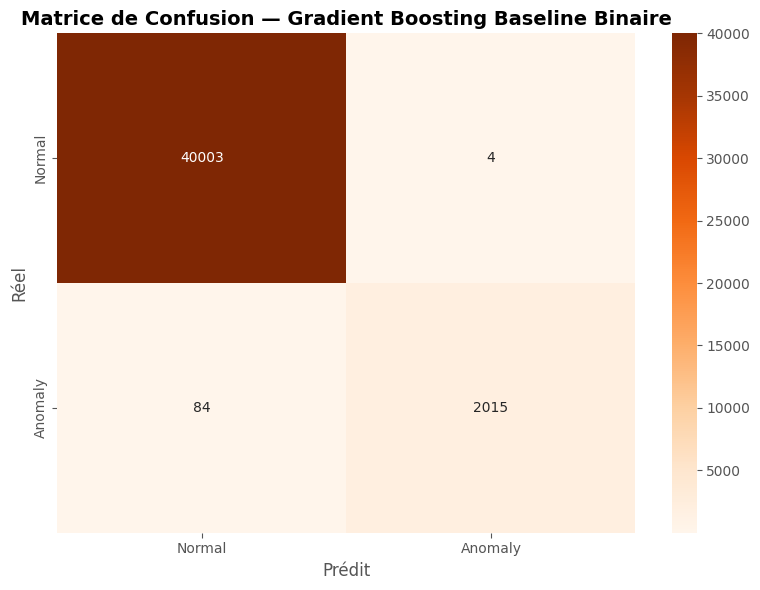

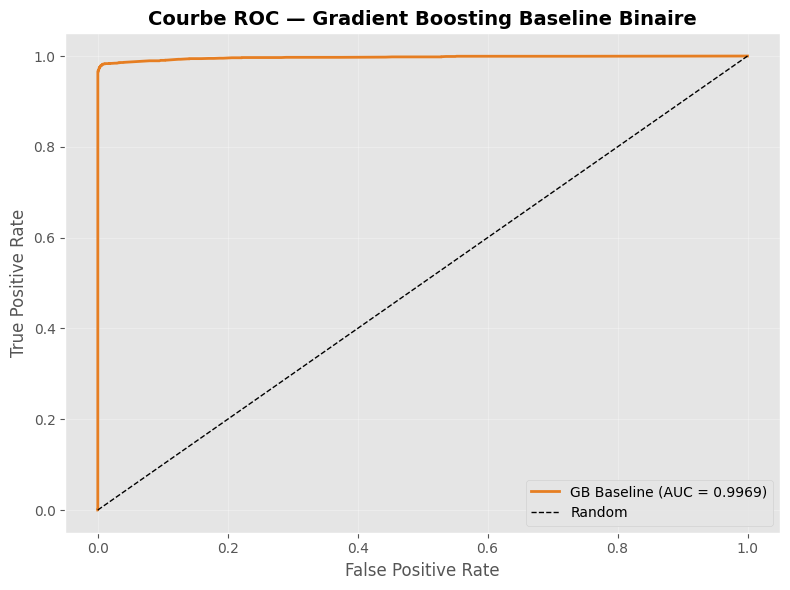

In [28]:
# =====================================================================
# 7.0.1 Gradient Boosting Baseline — Classification Binaire — SANS GridSearch
# =====================================================================
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
import time

# --- Modèle Baseline avec paramètres par défaut ---
print("="*70)
print("GRADIENT BOOSTING BASELINE — CLASSIFICATION BINAIRE (Données brutes)")
print("="*70)

gb_baseline_b = GradientBoostingClassifier(random_state=42)

print(f"\nParamètres par défaut:")
print(f"   n_estimators:      {gb_baseline_b.n_estimators}")
print(f"   learning_rate:     {gb_baseline_b.learning_rate}")
print(f"   max_depth:         {gb_baseline_b.max_depth}")
print(f"   min_samples_split: {gb_baseline_b.min_samples_split}")
print(f"   min_samples_leaf:  {gb_baseline_b.min_samples_leaf}")
print(f"   subsample:         {gb_baseline_b.subsample}")

# --- Entraînement ---
start_time = time.time()
gb_baseline_b.fit(X_train_b, y1_train)
train_time = time.time() - start_time
print(f"\n✅ Entraînement terminé en {train_time:.2f}s")

# --- Prédictions ---
y1_pred_baseline = gb_baseline_b.predict(X_test_b)
y1_proba_baseline = gb_baseline_b.predict_proba(X_test_b)[:, 1]

# --- Métriques d'évaluation ---
acc_baseline = accuracy_score(y1_test, y1_pred_baseline)
prec_baseline = precision_score(y1_test, y1_pred_baseline)
rec_baseline = recall_score(y1_test, y1_pred_baseline)
f1_baseline = f1_score(y1_test, y1_pred_baseline)
auc_baseline = roc_auc_score(y1_test, y1_proba_baseline)

print(f"\n{'='*70}")
print("RÉSULTATS BASELINE — Classification Binaire (Données brutes)")
print("="*70)
print(f"\n  Accuracy:  {acc_baseline:.4f}")
print(f"  Precision: {prec_baseline:.4f}")
print(f"  Recall:    {rec_baseline:.4f}")
print(f"  F1-Score:  {f1_baseline:.4f}")
print(f"  ROC-AUC:   {auc_baseline:.4f}")

print(f"\n📊 Classification Report:")
print(classification_report(y1_test, y1_pred_baseline, target_names=['Normal', 'Anomaly']))

# --- Matrice de confusion ---
cm_baseline = confusion_matrix(y1_test, y1_pred_baseline)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])
plt.title('Matrice de Confusion — Gradient Boosting Baseline Binaire', fontsize=14, fontweight='bold')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.tight_layout()
plt.show()

# --- Courbe ROC ---
fpr_bl, tpr_bl, _ = roc_curve(y1_test, y1_proba_baseline)

plt.figure(figsize=(8, 6))
plt.plot(fpr_bl, tpr_bl, color='#e67e22', linewidth=2, label=f'GB Baseline (AUC = {auc_baseline:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC — Gradient Boosting Baseline Binaire', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7.0 Baseline — Classification Multi-classes (Types d'anomalies)

GRADIENT BOOSTING BASELINE — CLASSIFICATION MULTI-CLASSES (Données brutes)

Paramètres par défaut:
   n_estimators:      100
   learning_rate:     0.1
   max_depth:         3
   min_samples_split: 2
   min_samples_leaf:  1

✅ Entraînement terminé en 424.69s

RÉSULTATS BASELINE — Classification Multi-classes (Données brutes)

  Accuracy:           0.9962
  Precision (weighted): 0.9962
  Recall (weighted):    0.9962
  F1-Score (weighted):  0.9961

📊 Classification Report:
                    precision    recall  f1-score   support

    backhaul_issue       0.98      1.00      0.99       260
  handover_failure       1.00      1.00      1.00       252
  hardware_failure       0.98      0.98      0.98       266
      interference       0.90      0.91      0.91       269
network_congestion       0.99      0.96      0.97       259
            normal       1.00      1.00      1.00     40007
          overload       0.90      0.91      0.90       265
   security_attack       0.98      0.99     

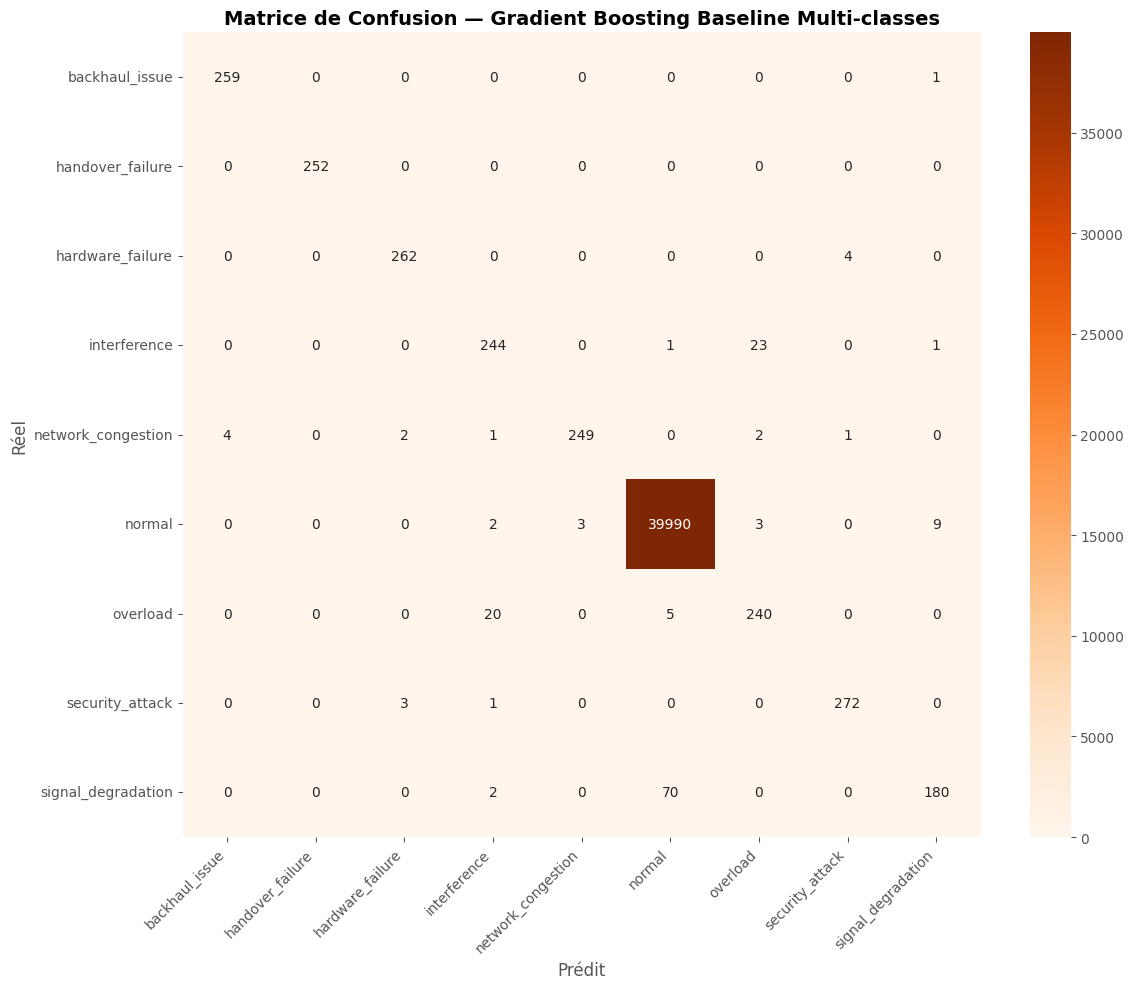


📋 RÉSUMÉ BASELINE GRADIENT BOOSTING (Paramètres par défaut)

  Métrique                     Binaire   Multi-classes
  --------------------------------------------------
  Accuracy                      0.9979          0.9962
  Precision                     0.9980          0.9962
  Recall                        0.9600          0.9962
  F1-Score                      0.9786          0.9961

⚠️  Ces résultats servent de RÉFÉRENCE pour évaluer l'amélioration
   apportée par l'optimisation des hyperparamètres (GridSearchCV).


In [29]:
# =====================================================================
# 7.0.2 Gradient Boosting Baseline — Classification Multi-classes — SANS GridSearch
# =====================================================================
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
import time

# --- Modèle Baseline Multi-classes avec paramètres par défaut ---
print("="*70)
print("GRADIENT BOOSTING BASELINE — CLASSIFICATION MULTI-CLASSES (Données brutes)")
print("="*70)

gb_baseline_m = GradientBoostingClassifier(random_state=42)

print(f"\nParamètres par défaut:")
print(f"   n_estimators:      {gb_baseline_m.n_estimators}")
print(f"   learning_rate:     {gb_baseline_m.learning_rate}")
print(f"   max_depth:         {gb_baseline_m.max_depth}")
print(f"   min_samples_split: {gb_baseline_m.min_samples_split}")
print(f"   min_samples_leaf:  {gb_baseline_m.min_samples_leaf}")

# --- Entraînement ---
start_time = time.time()
gb_baseline_m.fit(X_train_m, y2_train)
train_time = time.time() - start_time
print(f"\n✅ Entraînement terminé en {train_time:.2f}s")

# --- Prédictions ---
y2_pred_baseline = gb_baseline_m.predict(X_test_m)

# --- Métriques d'évaluation ---
acc_baseline_m = accuracy_score(y2_test, y2_pred_baseline)
prec_baseline_m = precision_score(y2_test, y2_pred_baseline, average='weighted')
rec_baseline_m = recall_score(y2_test, y2_pred_baseline, average='weighted')
f1_baseline_m = f1_score(y2_test, y2_pred_baseline, average='weighted')

print(f"\n{'='*70}")
print("RÉSULTATS BASELINE — Classification Multi-classes (Données brutes)")
print("="*70)
print(f"\n  Accuracy:           {acc_baseline_m:.4f}")
print(f"  Precision (weighted): {prec_baseline_m:.4f}")
print(f"  Recall (weighted):    {rec_baseline_m:.4f}")
print(f"  F1-Score (weighted):  {f1_baseline_m:.4f}")

print(f"\n📊 Classification Report:")
print(classification_report(y2_test, y2_pred_baseline, target_names=le_anomaly.classes_))

# --- Matrice de confusion ---
cm_baseline_m = confusion_matrix(y2_test, y2_pred_baseline)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_baseline_m, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le_anomaly.classes_,
            yticklabels=le_anomaly.classes_)
plt.title('Matrice de Confusion — Gradient Boosting Baseline Multi-classes', fontsize=14, fontweight='bold')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# --- Résumé Baseline ---
print(f"\n{'='*70}")
print("📋 RÉSUMÉ BASELINE GRADIENT BOOSTING (Paramètres par défaut)")
print("="*70)
print(f"\n  {'Métrique':<25} {'Binaire':>10} {'Multi-classes':>15}")
print(f"  {'-'*50}")
print(f"  {'Accuracy':<25} {acc_baseline:>10.4f} {acc_baseline_m:>15.4f}")
print(f"  {'Precision':<25} {prec_baseline:>10.4f} {prec_baseline_m:>15.4f}")
print(f"  {'Recall':<25} {rec_baseline:>10.4f} {rec_baseline_m:>15.4f}")
print(f"  {'F1-Score':<25} {f1_baseline:>10.4f} {f1_baseline_m:>15.4f}")
print(f"\n⚠️  Ces résultats servent de RÉFÉRENCE pour évaluer l'amélioration")
print(f"   apportée par l'optimisation des hyperparamètres (GridSearchCV).")

## 4. Modeling — Gradient Boosting (Raw Data)
Training the **Gradient Boosting** model on raw data (without normalization). Gradient Boosting, like decision trees, does not require normalization because it relies on split thresholds, not on distances.

### 4.1 Binary Classification — Gradient Boosting (Normal vs Anomaly)

In [30]:
# =====================================================================
# 4.1.1 Gradient Boosting — Binary Classification (Default Parameters)
# =====================================================================
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
import time

print("="*70)
print("GRADIENT BOOSTING — CLASSIFICATION BINAIRE (Normal vs Anomaly)")
print("="*70)

# Train the model with default parameters
start_time = time.time()
gb_binary = GradientBoostingClassifier(random_state=42)
gb_binary.fit(X_train_b, y1_train)
train_time = time.time() - start_time

# Predictions
start_pred = time.time()
y1_pred = gb_binary.predict(X_test_b)
y1_pred_proba = gb_binary.predict_proba(X_test_b)[:, 1]
pred_time = time.time() - start_pred

# Metrics
acc = accuracy_score(y1_test, y1_pred)
prec = precision_score(y1_test, y1_pred)
rec = recall_score(y1_test, y1_pred)
f1 = f1_score(y1_test, y1_pred)
roc_auc = roc_auc_score(y1_test, y1_pred_proba)

print(f"\n⏱️  Training time:   {train_time:.4f}s")
print(f"⏱️  Prediction time: {pred_time:.4f}s")
print(f"\n📊 METRICS (Default Parameters):")
print(f"   Accuracy:  {acc:.4f}  ({acc*100:.2f}%)")
print(f"   Precision: {prec:.4f}")
print(f"   Recall:    {rec:.4f}")
print(f"   F1-Score:  {f1:.4f}")
print(f"   ROC-AUC:   {roc_auc:.4f}")

print(f"\n📋 Classification Report:")
print(classification_report(y1_test, y1_pred, target_names=['Normal', 'Anomaly']))

# Model characteristics
print(f"\n🌲 Model Characteristics:")
print(f"   Number of estimators: {gb_binary.n_estimators}")
print(f"   Learning rate:        {gb_binary.learning_rate}")
print(f"   Max depth:            {gb_binary.max_depth}")
print(f"   Number of features:   {gb_binary.n_features_in_}")

GRADIENT BOOSTING — CLASSIFICATION BINAIRE (Normal vs Anomaly)

⏱️  Training time:   46.7849s
⏱️  Prediction time: 0.0651s

📊 METRICS (Default Parameters):
   Accuracy:  0.9979  (99.79%)
   Precision: 0.9980
   Recall:    0.9600
   F1-Score:  0.9786
   ROC-AUC:   0.9969

📋 Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     40007
     Anomaly       1.00      0.96      0.98      2099

    accuracy                           1.00     42106
   macro avg       1.00      0.98      0.99     42106
weighted avg       1.00      1.00      1.00     42106


🌲 Model Characteristics:
   Number of estimators: 100
   Learning rate:        0.1
   Max depth:            3
   Number of features:   16


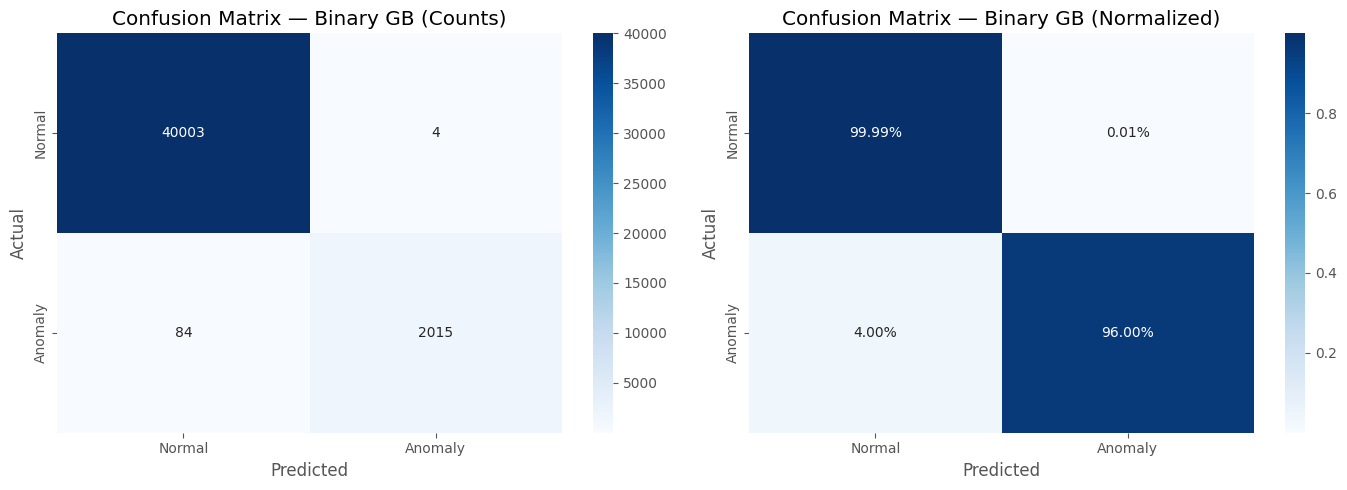


True Negatives  (TN) : 40003
False Positives (FP) : 4
False Negatives (FN) : 84
True Positives  (TP) : 2015

False Positive Rate (FPR) : 0.0001
False Negative Rate (FNR) : 0.0400


In [31]:
# ── 4.1.2  Confusion Matrix — Binary Gradient Boosting (Default) ──

from sklearn.metrics import confusion_matrix

cm_gb_b = confusion_matrix(y1_test, y1_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count-based matrix
sns.heatmap(cm_gb_b, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'], ax=axes[0])
axes[0].set_title('Confusion Matrix — Binary GB (Counts)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Normalized matrix
cm_gb_b_norm = cm_gb_b.astype('float') / cm_gb_b.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_gb_b_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'], ax=axes[1])
axes[1].set_title('Confusion Matrix — Binary GB (Normalized)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Extract TP, TN, FP, FN
tn, fp, fn, tp = cm_gb_b.ravel()
print(f"\nTrue Negatives  (TN) : {tn}")
print(f"False Positives (FP) : {fp}")
print(f"False Negatives (FN) : {fn}")
print(f"True Positives  (TP) : {tp}")
print(f"\nFalse Positive Rate (FPR) : {fp/(fp+tn):.4f}")
print(f"False Negative Rate (FNR) : {fn/(fn+tp):.4f}")

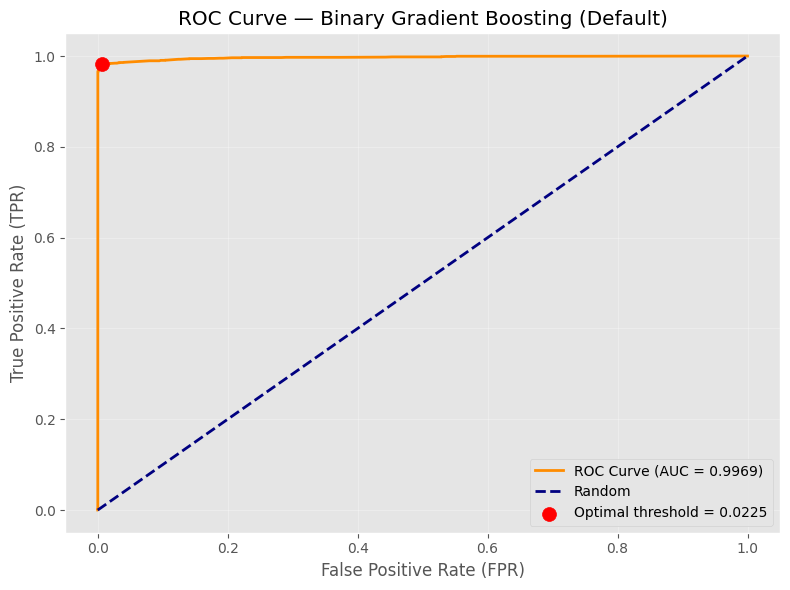

Optimal threshold (Youden's J) : 0.0225
TPR at optimal threshold       : 0.9819
FPR at optimal threshold       : 0.0072


In [32]:
# ── 4.1.3  ROC Curve — Binary Gradient Boosting (Default) ──

from sklearn.metrics import roc_curve, auc

y1_proba_b = gb_binary.predict_proba(X_test_b)[:, 1]
fpr, tpr, thresholds = roc_curve(y1_test, y1_proba_b)
roc_auc = auc(fpr, tpr)

# Optimal threshold (Youden's J)
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.scatter(fpr[best_idx], tpr[best_idx], color='red', s=100, zorder=5,
            label=f'Optimal threshold = {best_threshold:.4f}')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve — Binary Gradient Boosting (Default)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Optimal threshold (Youden's J) : {best_threshold:.4f}")
print(f"TPR at optimal threshold       : {tpr[best_idx]:.4f}")
print(f"FPR at optimal threshold       : {fpr[best_idx]:.4f}")

In [33]:
# ── 4.1.4  Cross-Validation — Binary Gradient Boosting (Default) ──

from sklearn.model_selection import cross_val_score

print("5-Fold Cross-Validation — Binary Gradient Boosting (Default)")
print("=" * 65)

scoring_metrics = ['accuracy', 'f1', 'roc_auc']
cv_results_gb_b = {}

for metric in scoring_metrics:
    scores = cross_val_score(gb_binary, X_train_b, y1_train,
                             cv=5, scoring=metric, n_jobs=-1)
    cv_results_gb_b[metric] = scores
    print(f"\n{metric.upper()}:")
    print(f"  Scores per fold : {scores.round(4)}")
    print(f"  Mean ± Std      : {scores.mean():.4f} ± {scores.std():.4f}")

print("\n" + "=" * 65)
print("Cross-Validation Summary:")
for metric, scores in cv_results_gb_b.items():
    print(f"  {metric:>10s} : {scores.mean():.4f} ± {scores.std():.4f}")

5-Fold Cross-Validation — Binary Gradient Boosting (Default)

ACCURACY:
  Scores per fold : [0.9977 0.9979 0.9979 0.9977 0.9977]
  Mean ± Std      : 0.9978 ± 0.0001

F1:
  Scores per fold : [0.977  0.9785 0.9782 0.9769 0.976 ]
  Mean ± Std      : 0.9773 ± 0.0009

ROC_AUC:
  Scores per fold : [0.9959 0.9971 0.9945 0.9958 0.9947]
  Mean ± Std      : 0.9956 ± 0.0009

Cross-Validation Summary:
    accuracy : 0.9978 ± 0.0001
          f1 : 0.9773 ± 0.0009
     roc_auc : 0.9956 ± 0.0009


### 4.2 Hyperparameter Tuning — Binary Gradient Boosting (GridSearchCV)

In [34]:
# ── 4.2.1  GridSearchCV — Binary Gradient Boosting ──

from sklearn.model_selection import GridSearchCV
import time

param_grid_gb_b = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'subsample': [0.8, 1.0]
}

print("GridSearchCV — Binary Gradient Boosting")
print("=" * 55)
total_combos = 1
for k, v in param_grid_gb_b.items():
    total_combos *= len(v)
    print(f"  {k}: {v}")
print(f"\nTotal number of combinations : {total_combos}")
print(f"With 3-fold CV : {total_combos * 3} fits")
print("\n⏳ Training in progress (this may take several minutes)...")

start_time = time.time()

grid_search_gb_b = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid_gb_b,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search_gb_b.fit(X_train_b, y1_train)

elapsed = time.time() - start_time
print(f"\n✅ GridSearchCV completed in {elapsed:.1f} seconds ({elapsed/60:.1f} minutes)")

print(f"\nBest hyperparameters:")
for param, value in grid_search_gb_b.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest F1 score (CV) : {grid_search_gb_b.best_score_:.4f}")

GridSearchCV — Binary Gradient Boosting
  n_estimators: [100, 200, 300]
  learning_rate: [0.01, 0.05, 0.1, 0.2]
  max_depth: [3, 5, 7]
  min_samples_split: [2, 5, 10]
  subsample: [0.8, 1.0]

Total number of combinations : 216
With 3-fold CV : 648 fits

⏳ Training in progress (this may take several minutes)...
Fitting 3 folds for each of 216 candidates, totalling 648 fits


KeyboardInterrupt: 

In [ ]:
# ── 4.2.2  Optimized Model Evaluation — Binary GB ──
gb_binary_best = grid_search_gb_b.best_estimator_

y1_pred_b_opt = gb_binary_best.predict(X_test_b)
y1_proba_b_opt = gb_binary_best.predict_proba(X_test_b)[:, 1]

acc_opt = accuracy_score(y1_test, y1_pred_b_opt)
prec_opt = precision_score(y1_test, y1_pred_b_opt)
rec_opt = recall_score(y1_test, y1_pred_b_opt)
f1_opt = f1_score(y1_test, y1_pred_b_opt)
roc_opt = roc_auc_score(y1_test, y1_proba_b_opt)

print("=" * 70)
print("COMPARISON: Binary Gradient Boosting — Default vs Optimized")
print("=" * 70)

# Default model metrics
acc_def = accuracy_score(y1_test, y1_pred)
prec_def = precision_score(y1_test, y1_pred)
rec_def = recall_score(y1_test, y1_pred)
f1_def = f1_score(y1_test, y1_pred)
roc_def = roc_auc_score(y1_test, y1_proba_b)

metrics_comparison = {
    'Accuracy':  (acc_def, acc_opt),
    'Precision': (prec_def, prec_opt),
    'Recall':    (rec_def, rec_opt),
    'F1-Score':  (f1_def, f1_opt),
    'ROC-AUC':   (roc_def, roc_opt)
}

print(f"{'Metric':<12} {'Default':>10} {'Optimized':>10} {'Δ':>10}")
print("-" * 45)
for metric, (default, optimized) in metrics_comparison.items():
    delta = optimized - default
    arrow = "↑" if delta > 0 else ("↓" if delta < 0 else "=")
    print(f"{metric:<12} {default:>10.4f} {optimized:>10.4f} {delta:>+10.4f} {arrow}")

print("\n" + "=" * 70)
print("\nClassification Report (Optimized):")
print(classification_report(y1_test, y1_pred_b_opt, target_names=['Normal', 'Anomaly']))

COMPARISON: Binary Gradient Boosting — Default vs Optimized
Metric          Default  Optimized          Δ
---------------------------------------------
Accuracy         0.9987     0.9997    +0.0010 ↑
Precision        1.0000     0.9960    -0.0040 ↓
Recall           0.9737     0.9980    +0.0242 ↑
F1-Score         0.9867     0.9970    +0.0103 ↑
ROC-AUC          1.0000     1.0000    +0.0000 ↑


Classification Report (Optimized):
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      9505
     Anomaly       1.00      1.00      1.00       495

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



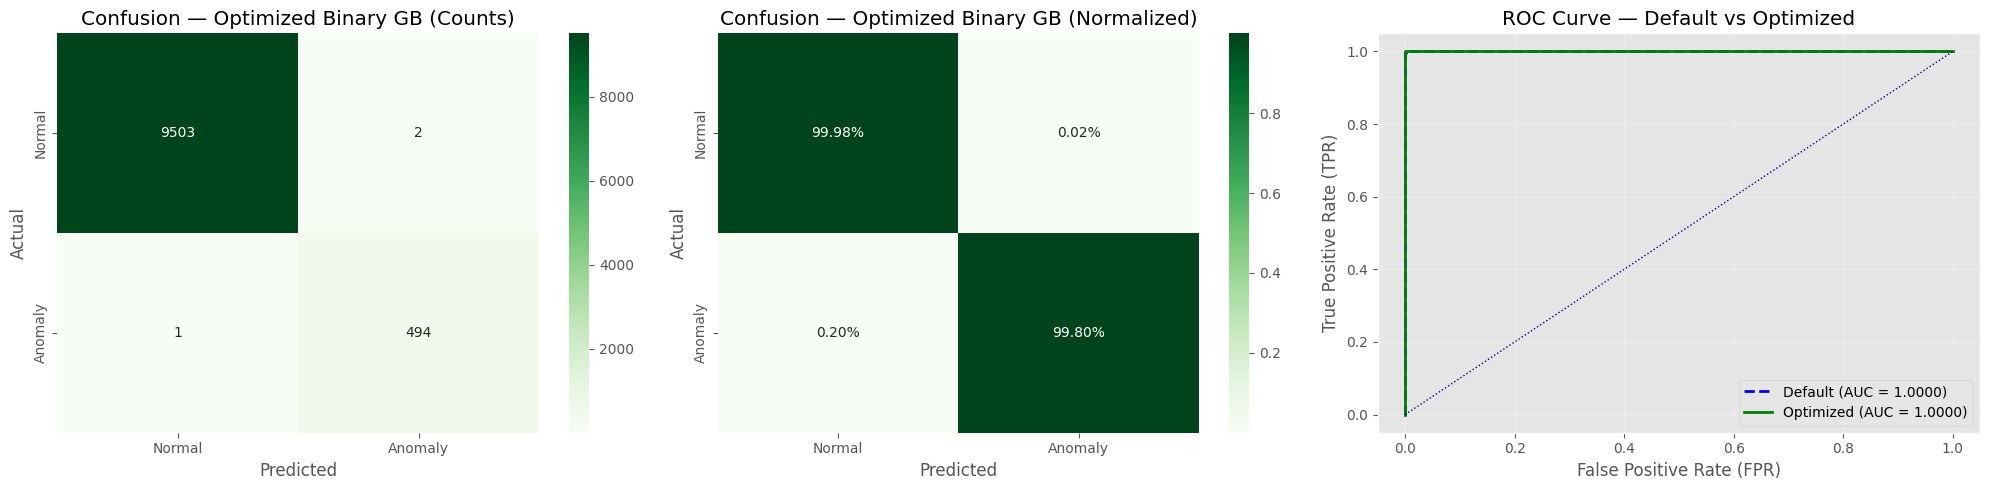

Default   → TN=9505, FP=0, FN=13, TP=482
Optimized → TN=9503, FP=2, FN=1, TP=494


In [ ]:
# ── 4.2.3  Confusion Matrix + ROC Curve — Optimized Binary GB ──

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Confusion matrix (counts)
cm_gb_b_opt = confusion_matrix(y1_test, y1_pred_b_opt)
sns.heatmap(cm_gb_b_opt, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'], ax=axes[0])
axes[0].set_title('Confusion — Optimized Binary GB (Counts)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# 2. Confusion matrix (normalized)
cm_gb_b_opt_norm = cm_gb_b_opt.astype('float') / cm_gb_b_opt.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_gb_b_opt_norm, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'], ax=axes[1])
axes[1].set_title('Confusion — Optimized Binary GB (Normalized)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# 3. ROC curve comparison
fpr_opt, tpr_opt, thresholds_opt = roc_curve(y1_test, y1_proba_b_opt)
roc_auc_opt = auc(fpr_opt, tpr_opt)

axes[2].plot(fpr, tpr, color='blue', lw=2, linestyle='--',
             label=f'Default (AUC = {roc_auc:.4f})')
axes[2].plot(fpr_opt, tpr_opt, color='green', lw=2,
             label=f'Optimized (AUC = {roc_auc_opt:.4f})')
axes[2].plot([0, 1], [0, 1], color='navy', lw=1, linestyle=':')
axes[2].set_xlabel('False Positive Rate (FPR)')
axes[2].set_ylabel('True Positive Rate (TPR)')
axes[2].set_title('ROC Curve — Default vs Optimized')
axes[2].legend(loc='lower right')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# TN, FP, FN, TP comparison
tn_o, fp_o, fn_o, tp_o = cm_gb_b_opt.ravel()
print(f"Default   → TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"Optimized → TN={tn_o}, FP={fp_o}, FN={fn_o}, TP={tp_o}")

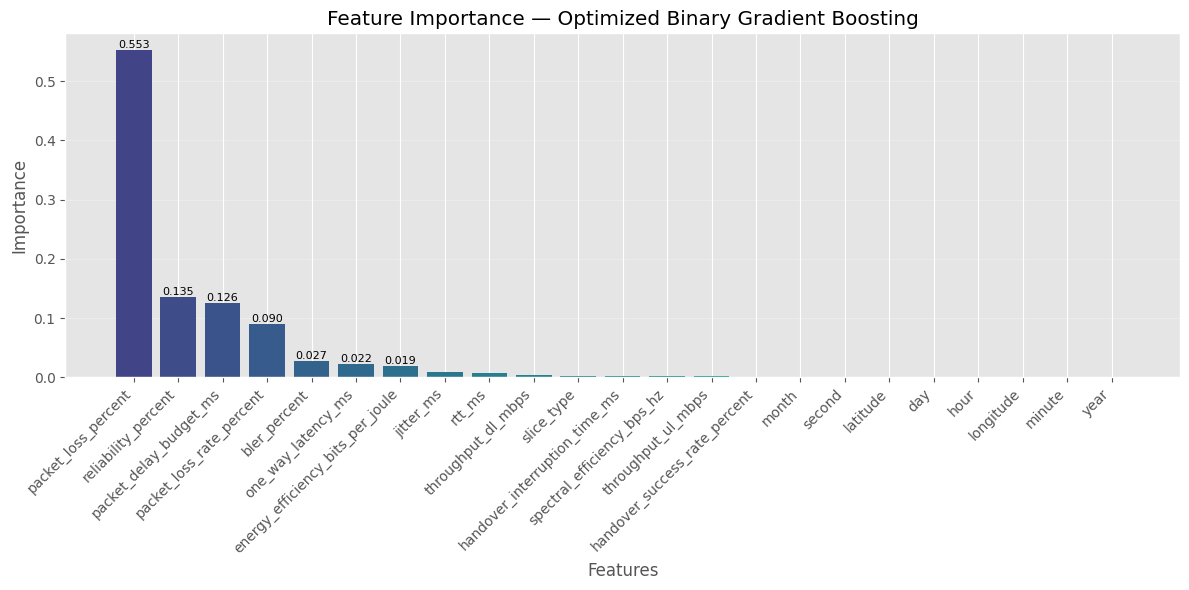

Top 10 Features — Optimized Binary GB:
----------------------------------------
   1. packet_loss_percent       : 0.5530
   2. reliability_percent       : 0.1350
   3. packet_delay_budget_ms    : 0.1257
   4. packet_loss_rate_percent  : 0.0896
   5. bler_percent              : 0.0267
   6. one_way_latency_ms        : 0.0225
   7. energy_efficiency_bits_per_joule : 0.0190
   8. jitter_ms                 : 0.0088
   9. rtt_ms                    : 0.0066
  10. throughput_dl_mbps        : 0.0035


In [ ]:
# ── 4.2.4  Feature Importance — Optimized Binary GB ──

feature_names = X_train_b.columns
importances_gb_b = gb_binary_best.feature_importances_

# Sort by descending importance
indices_gb_b = np.argsort(importances_gb_b)[::-1]

plt.figure(figsize=(12, 6))
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(feature_names)))
bars = plt.bar(range(len(feature_names)),
               importances_gb_b[indices_gb_b],
               color=colors)
plt.xticks(range(len(feature_names)),
           feature_names[indices_gb_b], rotation=45, ha='right')
plt.title('Feature Importance — Optimized Binary Gradient Boosting')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.grid(axis='y', alpha=0.3)

# Add values on bars
for bar, val in zip(bars, importances_gb_b[indices_gb_b]):
    if val > 0.01:
        plt.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                 f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Top 10 features
print("Top 10 Features — Optimized Binary GB:")
print("-" * 40)
for i in range(min(10, len(feature_names))):
    idx = indices_gb_b[i]
    print(f"  {i+1:2d}. {feature_names[idx]:<25s} : {importances_gb_b[idx]:.4f}")

### 4.3 Multi-Class Classification — Gradient Boosting

In [ ]:
# ── 4.3.1  Multi-Class Gradient Boosting — Default Parameters ──

print("=" * 70)
print("GRADIENT BOOSTING — MULTI-CLASS CLASSIFICATION (Default Parameters)")
print("=" * 70)

gb_multi = GradientBoostingClassifier(random_state=42)

start_time = time.time()
gb_multi.fit(X_train_m, y2_train)
train_time_m = time.time() - start_time

y2_pred_m = gb_multi.predict(X_test_m)

# Metrics
acc_m = accuracy_score(y2_test, y2_pred_m)
prec_m = precision_score(y2_test, y2_pred_m, average='weighted')
rec_m = recall_score(y2_test, y2_pred_m, average='weighted')
f1_m = f1_score(y2_test, y2_pred_m, average='weighted')

print(f"\nTraining time: {train_time_m:.1f}s")
print(f"\n{'Metric':<20} {'Value':>10}")
print("-" * 32)
print(f"{'Accuracy':<20} {acc_m:>10.4f}")
print(f"{'Precision (weighted)':<20} {prec_m:>10.4f}")
print(f"{'Recall (weighted)':<20} {rec_m:>10.4f}")
print(f"{'F1-Score (weighted)':<20} {f1_m:>10.4f}")

# Class names
class_names = [str(c) for c in sorted(np.unique(y2_test))]
print(f"\nNumber of classes: {len(class_names)}")
print(f"Classes: {class_names}")

print("\nClassification Report:")
print(classification_report(y2_test, y2_pred_m, target_names=class_names))

GRADIENT BOOSTING — MULTI-CLASS CLASSIFICATION (Default Parameters)

Training time: 180.0s

Metric                    Value
--------------------------------
Accuracy                 0.9980
Precision (weighted)     0.9980
Recall (weighted)        0.9980
F1-Score (weighted)      0.9980

Number of classes: 9
Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8']

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98        64
           1       1.00      1.00      1.00        56
           2       1.00      1.00      1.00        63
           3       0.90      0.97      0.93        62
           4       0.95      0.97      0.96        62
           5       1.00      1.00      1.00      9505
           6       0.97      0.92      0.94        62
           7       1.00      0.98      0.99        62
           8       0.95      0.92      0.94        64

    accuracy                           1.00     10000
   macro avg      

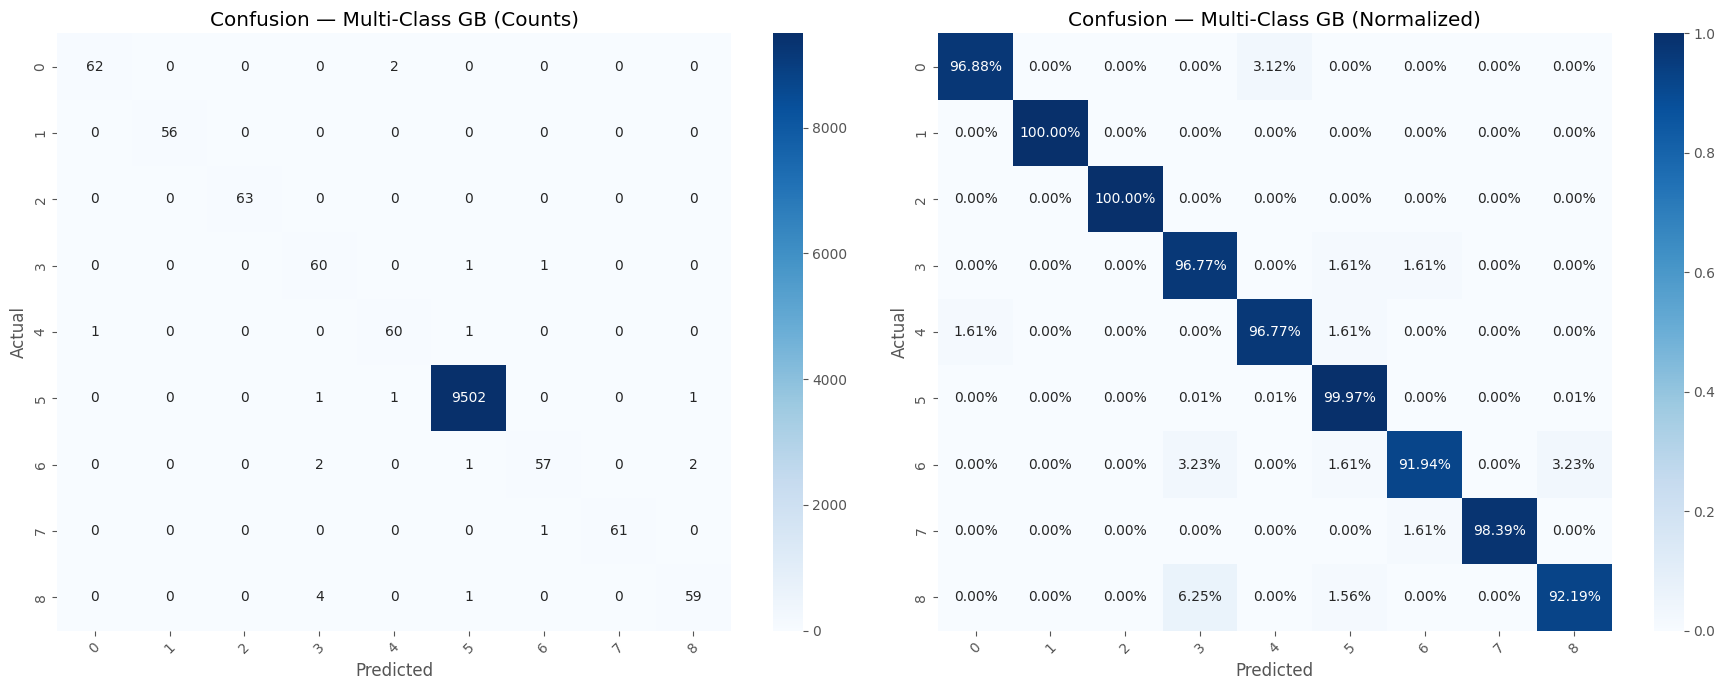

Per-class accuracy (normalized diagonal):
---------------------------------------------
  0                         : 96.88%
  1                         : 100.00%
  2                         : 100.00%
  3                         : 96.77%
  4                         : 96.77%
  5                         : 99.97%
  6                         : 91.94%
  7                         : 98.39%
  8                         : 92.19%


In [ ]:
# ── 4.3.2  Confusion Matrix — Multi-Class GB (Default) ──

cm_gb_m = confusion_matrix(y2_test, y2_pred_m)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Count-based matrix
sns.heatmap(cm_gb_m, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Confusion — Multi-Class GB (Counts)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].tick_params(axis='x', rotation=45)

# Normalized matrix
cm_gb_m_norm = cm_gb_m.astype('float') / cm_gb_m.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_gb_m_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Confusion — Multi-Class GB (Normalized)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Per-class accuracy
print("Per-class accuracy (normalized diagonal):")
print("-" * 45)
for i, cls in enumerate(class_names):
    print(f"  {cls:<25s} : {cm_gb_m_norm[i, i]:.2%}")

### 4.4 Hyperparameter Tuning — Multi-Class Gradient Boosting (GridSearchCV)

In [ ]:
# ── 4.4.1  GridSearchCV — Multi-Class Gradient Boosting ──

param_grid_gb_m = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'subsample': [0.8, 1.0]
}

print("GridSearchCV — Multi-Class Gradient Boosting")
print("=" * 55)
total_combos_m = 1
for k, v in param_grid_gb_m.items():
    total_combos_m *= len(v)
    print(f"  {k}: {v}")
print(f"\nTotal number of combinations: {total_combos_m}")
print(f"With 3-fold CV: {total_combos_m * 3} fits")
print("\n⏳ Training in progress (this may take several minutes)...")

start_time = time.time()

grid_search_gb_m = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid_gb_m,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

grid_search_gb_m.fit(X_train_m, y2_train)

elapsed_m = time.time() - start_time
print(f"\n✅ GridSearchCV completed in {elapsed_m:.1f} seconds ({elapsed_m/60:.1f} minutes)")

print(f"\nBest hyperparameters:")
for param, value in grid_search_gb_m.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest F1 weighted score (CV): {grid_search_gb_m.best_score_:.4f}")

GridSearchCV — Multi-Class Gradient Boosting
  n_estimators: [100, 200, 300]
  learning_rate: [0.01, 0.05, 0.1, 0.2]
  max_depth: [3, 5, 7]
  min_samples_split: [2, 5, 10]
  subsample: [0.8, 1.0]

Total number of combinations: 216
With 3-fold CV: 648 fits

⏳ Training in progress (this may take several minutes)...
Fitting 3 folds for each of 216 candidates, totalling 648 fits

✅ GridSearchCV completed in 19989.3 seconds (333.2 minutes)

Best hyperparameters:
  learning_rate: 0.05
  max_depth: 3
  min_samples_split: 5
  n_estimators: 300
  subsample: 1.0

Best F1 weighted score (CV): 0.9990


In [ ]:
# ── 4.4.2  Optimized Model Evaluation — Multi-Class GB ──

gb_multi_best = grid_search_gb_m.best_estimator_

y2_pred_m_opt = gb_multi_best.predict(X_test_m)

acc_m_opt = accuracy_score(y2_test, y2_pred_m_opt)
prec_m_opt = precision_score(y2_test, y2_pred_m_opt, average='weighted')
rec_m_opt = recall_score(y2_test, y2_pred_m_opt, average='weighted')
f1_m_opt = f1_score(y2_test, y2_pred_m_opt, average='weighted')

print("=" * 70)
print("COMPARISON: Multi-Class GB — Default vs Optimized")
print("=" * 70)

metrics_comp_m = {
    'Accuracy':           (acc_m, acc_m_opt),
    'Precision (weighted)':(prec_m, prec_m_opt),
    'Recall (weighted)':  (rec_m, rec_m_opt),
    'F1-Score (weighted)':(f1_m, f1_m_opt)
}

print(f"{'Metric':<22} {'Default':>10} {'Optimized':>10} {'Δ':>10}")
print("-" * 55)
for metric, (default, optimized) in metrics_comp_m.items():
    delta = optimized - default
    arrow = "↑" if delta > 0 else ("↓" if delta < 0 else "=")
    print(f"{metric:<22} {default:>10.4f} {optimized:>10.4f} {delta:>+10.4f} {arrow}")

print("\nClassification Report (Optimized):")
print(classification_report(y2_test, y2_pred_m_opt, target_names=class_names))

COMPARISON: Multi-Class GB — Default vs Optimized
Metric                    Default  Optimized          Δ
-------------------------------------------------------
Accuracy                   0.9980     0.9997    +0.0017 ↑
Precision (weighted)       0.9980     0.9997    +0.0017 ↑
Recall (weighted)          0.9980     0.9997    +0.0017 ↑
F1-Score (weighted)        0.9980     0.9997    +0.0017 ↑

Classification Report (Optimized):
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        64
           1       1.00      1.00      1.00        56
           2       1.00      1.00      1.00        63
           3       1.00      0.98      0.99        62
           4       0.98      1.00      0.99        62
           5       1.00      1.00      1.00      9505
           6       1.00      0.98      0.99        62
           7       1.00      1.00      1.00        62
           8       1.00      1.00      1.00        64

    accuracy                

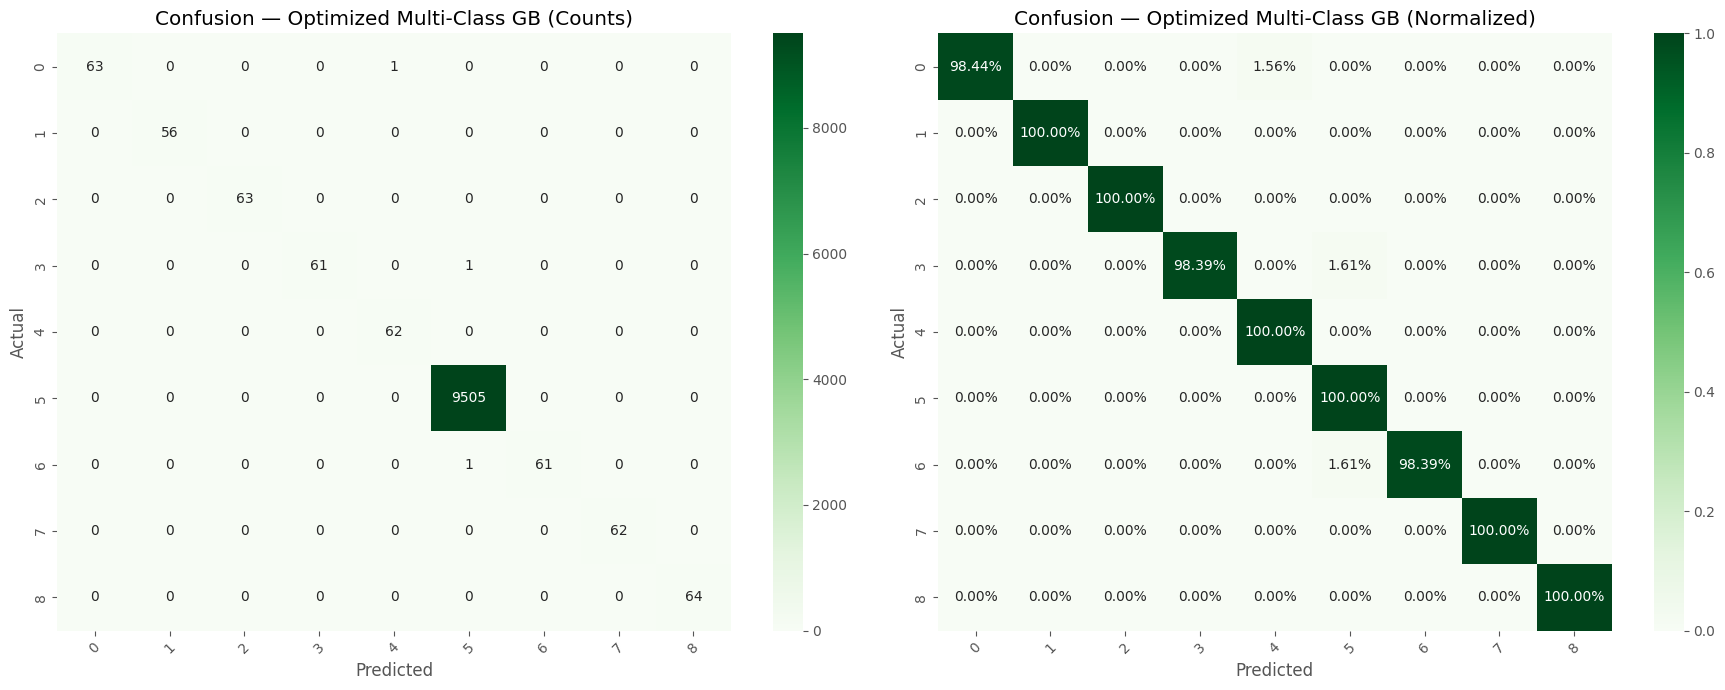

Per-class accuracy — Default vs Optimized:
-------------------------------------------------------
Class                        Default  Optimized        Δ
-------------------------------------------------------
  0                           96.88%     98.44%   +1.56% ↑
  1                          100.00%    100.00%   +0.00% =
  2                          100.00%    100.00%   +0.00% =
  3                           96.77%     98.39%   +1.61% ↑
  4                           96.77%    100.00%   +3.23% ↑
  5                           99.97%    100.00%   +0.03% ↑
  6                           91.94%     98.39%   +6.45% ↑
  7                           98.39%    100.00%   +1.61% ↑
  8                           92.19%    100.00%   +7.81% ↑


In [ ]:
# ── 4.4.3  Confusion Matrix — Optimized Multi-Class GB ──

cm_gb_m_opt = confusion_matrix(y2_test, y2_pred_m_opt)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Counts
sns.heatmap(cm_gb_m_opt, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Confusion — Optimized Multi-Class GB (Counts)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].tick_params(axis='x', rotation=45)

# Normalized
cm_gb_m_opt_norm = cm_gb_m_opt.astype('float') / cm_gb_m_opt.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_gb_m_opt_norm, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Confusion — Optimized Multi-Class GB (Normalized)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Per-class accuracy comparison
print("Per-class accuracy — Default vs Optimized:")
print("-" * 55)
print(f"{'Class':<25s} {'Default':>10s} {'Optimized':>10s} {'Δ':>8s}")
print("-" * 55)
for i, cls in enumerate(class_names):
    def_val = cm_gb_m_norm[i, i]
    opt_val = cm_gb_m_opt_norm[i, i]
    delta = opt_val - def_val
    arrow = "↑" if delta > 0 else ("↓" if delta < 0 else "=")
    print(f"  {cls:<23s} {def_val:>10.2%} {opt_val:>10.2%} {delta:>+8.2%} {arrow}")

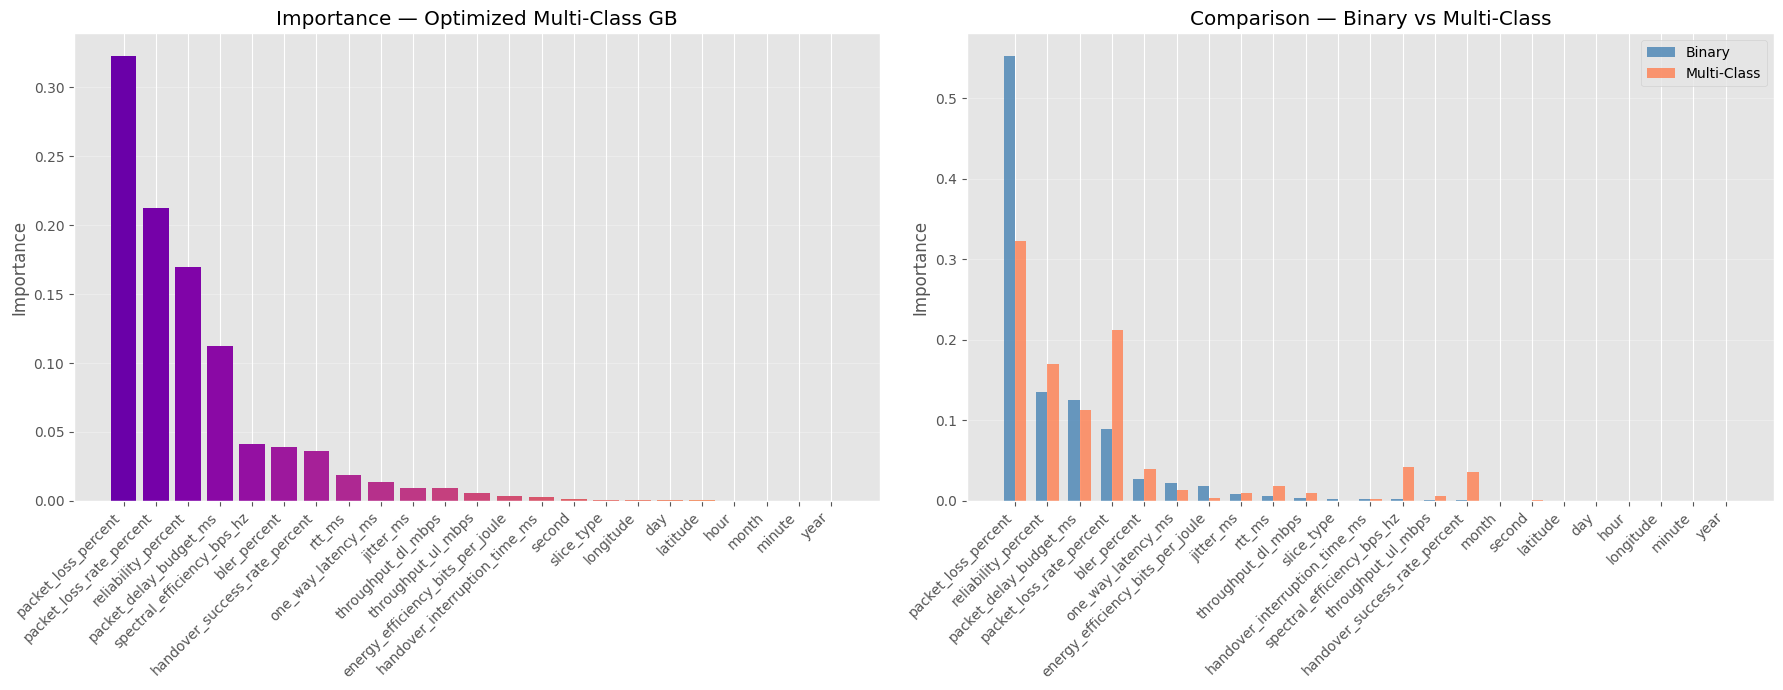

Top 10 Features — Optimized Multi-Class GB:
----------------------------------------
   1. packet_loss_percent       : 0.3231
   2. packet_loss_rate_percent  : 0.2124
   3. reliability_percent       : 0.1696
   4. packet_delay_budget_ms    : 0.1127
   5. spectral_efficiency_bps_hz : 0.0415
   6. bler_percent              : 0.0390
   7. handover_success_rate_percent : 0.0361
   8. rtt_ms                    : 0.0184
   9. one_way_latency_ms        : 0.0138
  10. jitter_ms                 : 0.0095


In [ ]:
# ── 4.4.4  Feature Importance — Multi-Class GB (+ Comparison) ──

importances_gb_m = gb_multi_best.feature_importances_
indices_gb_m = np.argsort(importances_gb_m)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Feature importance — Multi-Class
colors_m = plt.cm.plasma(np.linspace(0.2, 0.8, len(feature_names)))
bars_m = axes[0].bar(range(len(feature_names)),
                     importances_gb_m[indices_gb_m], color=colors_m)
axes[0].set_xticks(range(len(feature_names)))
axes[0].set_xticklabels(feature_names[indices_gb_m], rotation=45, ha='right')
axes[0].set_title('Importance — Optimized Multi-Class GB')
axes[0].set_ylabel('Importance')
axes[0].grid(axis='y', alpha=0.3)

# Comparison Binary vs Multi-Class
x_pos = np.arange(len(feature_names))
width = 0.35
axes[1].bar(x_pos - width/2, importances_gb_b[indices_gb_b], width,
            label='Binary', color='steelblue', alpha=0.8)
axes[1].bar(x_pos + width/2, importances_gb_m[indices_gb_b], width,
            label='Multi-Class', color='coral', alpha=0.8)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(feature_names[indices_gb_b], rotation=45, ha='right')
axes[1].set_title('Comparison — Binary vs Multi-Class')
axes[1].set_ylabel('Importance')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Top 10 features Multi-Class
print("Top 10 Features — Optimized Multi-Class GB:")
print("-" * 40)
for i in range(min(10, len(feature_names))):
    idx = indices_gb_m[i]
    print(f"  {i+1:2d}. {feature_names[idx]:<25s} : {importances_gb_m[idx]:.4f}")

### 4.5 Overfitting Analysis — Gradient Boosting

OVERFITTING ANALYSIS — GRADIENT BOOSTING

Model                      Train Acc   Test Acc    Δ Acc   Train F1    Test F1     Δ F1
-------------------------------------------------------------------------------------
GB Binary (opt.)              1.0000     0.9997  +0.0003     1.0000     0.9970  +0.0030
GB Multi-Class (opt.)         1.0000     0.9997  +0.0003     1.0000     0.9997  +0.0003


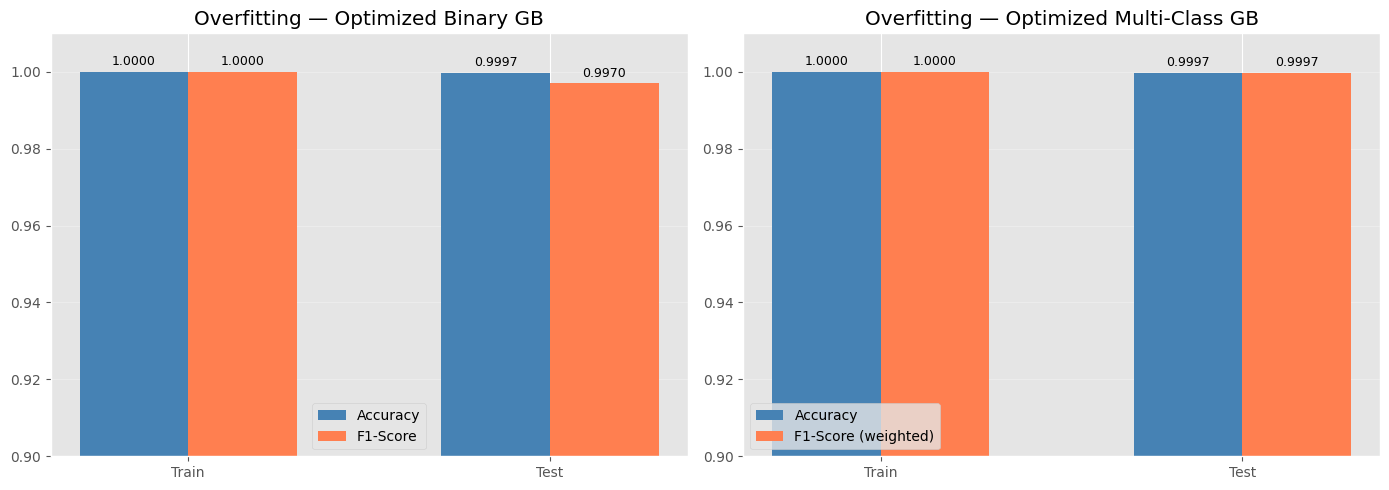


📊 Interpretation:
  ✅ GB Binary: No significant overfitting (Δ Accuracy=+0.0003, Δ F1=+0.0030)
  ✅ GB Multi-Class: No significant overfitting (Δ Accuracy=+0.0003, Δ F1=+0.0003)


In [ ]:
# ── 4.5.1  Overfitting Analysis — Train vs Test ──

print("=" * 75)
print("OVERFITTING ANALYSIS — GRADIENT BOOSTING")
print("=" * 75)

# ── Optimized Binary ──
y1_train_pred = gb_binary_best.predict(X_train_b)
y1_test_pred = gb_binary_best.predict(X_test_b)

train_acc_b = accuracy_score(y1_train, y1_train_pred)
test_acc_b = accuracy_score(y1_test, y1_test_pred)
train_f1_b = f1_score(y1_train, y1_train_pred)
test_f1_b = f1_score(y1_test, y1_test_pred)

# ── Optimized Multi-Class ──
y2_train_pred = gb_multi_best.predict(X_train_m)
y2_test_pred = gb_multi_best.predict(X_test_m)

train_acc_m = accuracy_score(y2_train, y2_train_pred)
test_acc_m = accuracy_score(y2_test, y2_test_pred)
train_f1_m = f1_score(y2_train, y2_train_pred, average='weighted')
test_f1_m = f1_score(y2_test, y2_test_pred, average='weighted')

# Summary table
print(f"\n{'Model':<25} {'Train Acc':>10} {'Test Acc':>10} {'Δ Acc':>8} {'Train F1':>10} {'Test F1':>10} {'Δ F1':>8}")
print("-" * 85)

delta_acc_b = train_acc_b - test_acc_b
delta_f1_b = train_f1_b - test_f1_b
print(f"{'GB Binary (opt.)':<25} {train_acc_b:>10.4f} {test_acc_b:>10.4f} {delta_acc_b:>+8.4f} {train_f1_b:>10.4f} {test_f1_b:>10.4f} {delta_f1_b:>+8.4f}")

delta_acc_m = train_acc_m - test_acc_m
delta_f1_m = train_f1_m - test_f1_m
print(f"{'GB Multi-Class (opt.)':<25} {train_acc_m:>10.4f} {test_acc_m:>10.4f} {delta_acc_m:>+8.4f} {train_f1_m:>10.4f} {test_f1_m:>10.4f} {delta_f1_m:>+8.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Binary
models_b = ['Train', 'Test']
acc_vals_b = [train_acc_b, test_acc_b]
f1_vals_b = [train_f1_b, test_f1_b]

x = np.arange(len(models_b))
width = 0.3
axes[0].bar(x - width/2, acc_vals_b, width, label='Accuracy', color='steelblue')
axes[0].bar(x + width/2, f1_vals_b, width, label='F1-Score', color='coral')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models_b)
axes[0].set_ylim(0.9, 1.01)
axes[0].set_title('Overfitting — Optimized Binary GB')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
for i, (a, f) in enumerate(zip(acc_vals_b, f1_vals_b)):
    axes[0].text(i - width/2, a + 0.001, f'{a:.4f}', ha='center', va='bottom', fontsize=9)
    axes[0].text(i + width/2, f + 0.001, f'{f:.4f}', ha='center', va='bottom', fontsize=9)

# Multi-Class
acc_vals_m = [train_acc_m, test_acc_m]
f1_vals_m = [train_f1_m, test_f1_m]

axes[1].bar(x - width/2, acc_vals_m, width, label='Accuracy', color='steelblue')
axes[1].bar(x + width/2, f1_vals_m, width, label='F1-Score (weighted)', color='coral')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models_b)
axes[1].set_ylim(0.9, 1.01)
axes[1].set_title('Overfitting — Optimized Multi-Class GB')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
for i, (a, f) in enumerate(zip(acc_vals_m, f1_vals_m)):
    axes[1].text(i - width/2, a + 0.001, f'{a:.4f}', ha='center', va='bottom', fontsize=9)
    axes[1].text(i + width/2, f + 0.001, f'{f:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Interpretation
print("\n📊 Interpretation:")
threshold = 0.02
for name, d_acc, d_f1 in [("Binary", delta_acc_b, delta_f1_b),
                            ("Multi-Class", delta_acc_m, delta_f1_m)]:
    if d_acc > threshold or d_f1 > threshold:
        print(f"  ⚠️  GB {name}: Signs of overfitting (Δ Accuracy={d_acc:+.4f}, Δ F1={d_f1:+.4f})")
    else:
        print(f"  ✅ GB {name}: No significant overfitting (Δ Accuracy={d_acc:+.4f}, Δ F1={d_f1:+.4f})")

### 4.6 Global Summary — Gradient Boosting

In [ ]:
# ── 4.6  Global Summary — Gradient Boosting ──

import pandas as pd

print("=" * 80)
print("GLOBAL SUMMARY — GRADIENT BOOSTING FOR 5G ANOMALY DETECTION")
print("=" * 80)

# Summary table
summary_data = {
    'Model': [
        'GB Binary (default)',
        'GB Binary (optimized)',
        'GB Multi-Class (default)',
        'GB Multi-Class (optimized)'
    ],
    'Accuracy': [
        accuracy_score(y1_test, y1_pred),
        accuracy_score(y1_test, y1_pred_b_opt),
        accuracy_score(y2_test, y2_pred_m),
        accuracy_score(y2_test, y2_pred_m_opt)
    ],
    'Precision': [
        precision_score(y1_test, y1_pred),
        precision_score(y1_test, y1_pred_b_opt),
        precision_score(y2_test, y2_pred_m, average='weighted'),
        precision_score(y2_test, y2_pred_m_opt, average='weighted')
    ],
    'Recall': [
        recall_score(y1_test, y1_pred),
        recall_score(y1_test, y1_pred_b_opt),
        recall_score(y2_test, y2_pred_m, average='weighted'),
        recall_score(y2_test, y2_pred_m_opt, average='weighted')
    ],
    'F1-Score': [
        f1_score(y1_test, y1_pred),
        f1_score(y1_test, y1_pred_b_opt),
        f1_score(y2_test, y2_pred_m, average='weighted'),
        f1_score(y2_test, y2_pred_m_opt, average='weighted')
    ]
}

df_summary = pd.DataFrame(summary_data)
df_summary = df_summary.round(4)

print("\n📊 Summary Table:")
print(df_summary.to_string(index=False))

# Best hyperparameters
print("\n\n🔧 Best Hyperparameters (GridSearchCV):")
print("\n  Binary:")
for param, value in grid_search_gb_b.best_params_.items():
    print(f"    {param}: {value}")

print("\n  Multi-Class:")
for param, value in grid_search_gb_m.best_params_.items():
    print(f"    {param}: {value}")

# Overfitting
print("\n\n📈 Overfitting Analysis (Train - Test):")
print(f"  Binary      : Δ Accuracy = {delta_acc_b:+.4f}, Δ F1 = {delta_f1_b:+.4f}")
print(f"  Multi-Class : Δ Accuracy = {delta_acc_m:+.4f}, Δ F1 = {delta_f1_m:+.4f}")

# Top 5 features
print("\n\n🏆 Top 5 Most Important Features:")
print("\n  Binary:")
for i in range(5):
    idx = indices_gb_b[i]
    print(f"    {i+1}. {feature_names[idx]:<25s} ({importances_gb_b[idx]:.4f})")
print("\n  Multi-Class:")
for i in range(5):
    idx = indices_gb_m[i]
    print(f"    {i+1}. {feature_names[idx]:<25s} ({importances_gb_m[idx]:.4f})")

print("\n" + "=" * 80)

GLOBAL SUMMARY — GRADIENT BOOSTING FOR 5G ANOMALY DETECTION

📊 Summary Table:
                     Model  Accuracy  Precision  Recall  F1-Score
       GB Binary (default)    0.9987     1.0000  0.9737    0.9867
     GB Binary (optimized)    0.9997     0.9960  0.9980    0.9970
  GB Multi-Class (default)    0.9980     0.9980  0.9980    0.9980
GB Multi-Class (optimized)    0.9997     0.9997  0.9997    0.9997


🔧 Best Hyperparameters (GridSearchCV):

  Binary:
    learning_rate: 0.1
    max_depth: 7
    min_samples_split: 2
    n_estimators: 300
    subsample: 0.8

  Multi-Class:
    learning_rate: 0.05
    max_depth: 3
    min_samples_split: 5
    n_estimators: 300
    subsample: 1.0


📈 Overfitting Analysis (Train - Test):
  Binary      : Δ Accuracy = +0.0003, Δ F1 = +0.0030
  Multi-Class : Δ Accuracy = +0.0003, Δ F1 = +0.0003


🏆 Top 5 Most Important Features:

  Binary:
    1. packet_loss_percent       (0.5530)
    2. reliability_percent       (0.1350)
    3. packet_delay_budget_ms    (